# Práctica 1 - Visión por Computador
## Marcial Galván - Alejandra Rodríguez

### Tabla de contenidos
- [Tarea 1 - Tablero de ajedrez](#tarea-1---tablero-de-ajedrez)
    - [De forma manual](#de-forma-manual)
    - [Con inteligencia artificial](#con-inteligencia-artificial)
- [Tarea 2 - Arte al estilo de Mondrian](#tarea-2---arte-al-estilo-de-mondrian)
- [Tarea 3 - Detección de píxeles en vídeo](#tarea-3---detección-de-píxeles-en-vídeo)
- [Tarea 4 - Pop Art al estilo de Warhol](#tarea-4---pop-art-al-estilo-de-warhol)

In [2]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
import random

### Tarea 1 - Tablero de ajedrez

Crear una imagen de 800x800 píxeles con la textura del tablero de ajedrez.

In [4]:
width = 800
height = 800

#### De forma manual

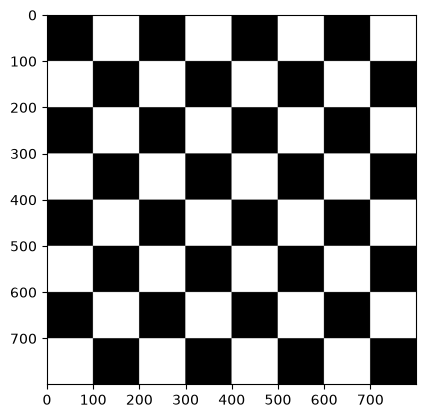

In [135]:
class Chess:
    def __init__(self, width=800, height=800, rows=8, cols=8):
        self.width = width
        self.height = height
        self.rows = rows
        self.cols = cols
        self.step_x= int((height)/rows)
        self.step_y= int((width)/cols)
        self.image = np.zeros((height,width, 1), dtype = np.uint8)
        self.__draw()
    
    def __get_color(self, x, y):
        return 255*((x+y)%2)
    
    def __draw(self):
        for y in range(self.rows):
            for x in range(self.cols):
                start_shell_x, start_shell_y = x*self.step_x, y*self.step_y
                self.image[start_shell_x:(start_shell_x+self.step_x), start_shell_y:(start_shell_y+self.step_y)] = self.__get_color(x, y)
    
    def plot(self):
        plt.imshow(self.image, cmap="gray") 
        plt.show()



Chess().plot()

#### Con inteligencia artificial

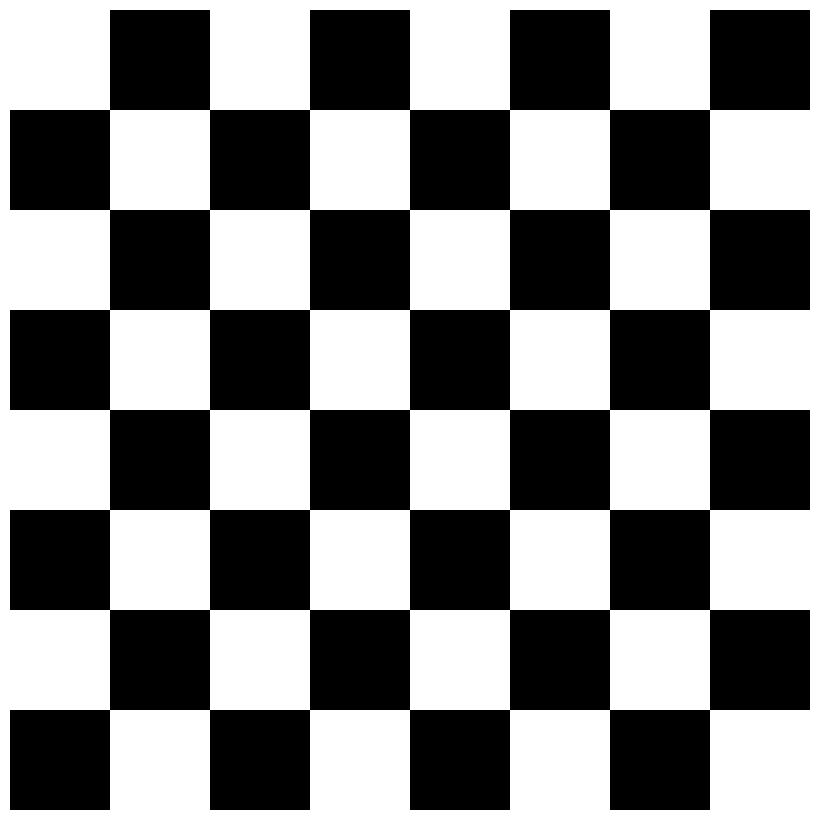

In [9]:
# Claude
# --- Parámetros ---
SQUARES = 8          # número de casillas por lado (tablero clásico 8x8)
SQ = width // SQUARES  # tamaño de cada casilla en píxeles
 
LIGHT = 255  # blanco
DARK = 0     # negro
 
# --- Construcción del patrón con numpy ---
# Índices de fila/columna de casilla para cada píxel
rows = np.arange(height) // SQ
cols = np.arange(width) // SQ
 
# Máscara booleana: True donde (fila+columna) es par -> casilla clara
row_grid, col_grid = np.meshgrid(rows, cols, indexing="ij")
mask = (row_grid + col_grid) % 2 == 0
 
# Imagen en escala de grises: un solo canal (width, height)
img = np.where(mask, LIGHT, DARK).astype(np.uint8)
 
# --- Visualización con matplotlib ---
fig, ax = plt.subplots(figsize=(width / 100, height / 100), dpi=100)
ax.imshow(img, cmap="gray", vmin=0, vmax=255)
ax.axis("off")
fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
 
plt.show()

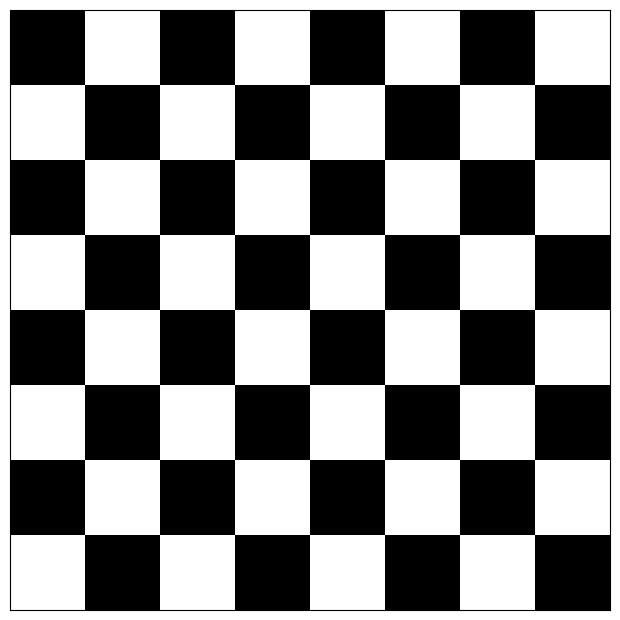

In [6]:
# ChatGPT
# Create an 8x8 chessboard using only grayscale values
board = np.indices((8, 8)).sum(axis=0) % 2

fig, ax = plt.subplots(figsize=(width / 100, height / 100), dpi=100)

# Map 0 -> white and 1 -> gray, with a grayscale colormap
ax.imshow(board, cmap="gray", vmin=0, vmax=1, interpolation="nearest")

# Remove axes, ticks, and margins
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")
fig.subplots_adjust(left=0, right=1, bottom=0, top=1)

plt.show()

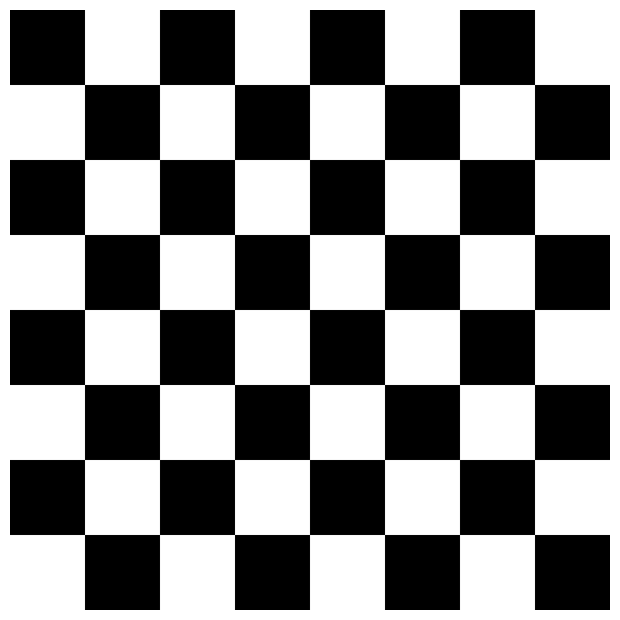

In [7]:
# Gemini
# Create an 8x8 checkerboard pattern (0 = black, 255 = white)
# Shape is (8, 8), single-channel uint8 array
board_8x8 = np.fromfunction(lambda i, j: (i + j) % 2 * 255, (8, 8), dtype=np.uint8)

# Scale up each 1x1 tile to 100x100 pixels to achieve an 800x800 resolution
chessboard = np.repeat(np.repeat(board_8x8, 100, axis=0), 100, axis=1)

# Set figure size to 8x8 inches at 100 DPI for exactly 800x800 pixels
plt.figure(figsize=(width / 100, height / 100), dpi=100)

# Render as grayscale (1 single color channel)
plt.imshow(chessboard, cmap='gray', vmin=0, vmax=255)

# Hide axes tick marks and borders
plt.axis('off')
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

plt.show()

### Tarea 2 - Arte al estilo de Mondrian

Crear una imagen [estilo Mondrian](https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.

In [2]:
width = 300
height = 200

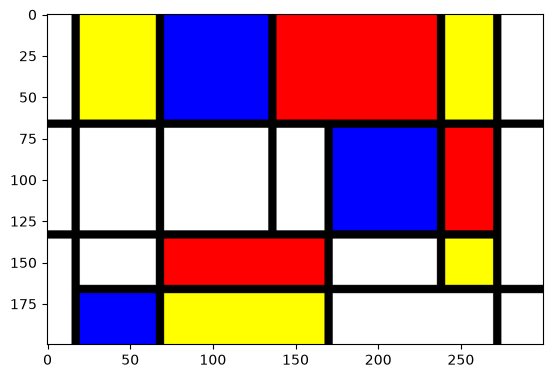

In [ ]:
def add_horizontal_lines():
    cv2.line(mondrian_img, (0, layers[0]), (width, layers[0]), line_color, 3)
    cv2.line(mondrian_img, (0, layers[1]), (x_step*16, layers[1]), line_color, 3)
    cv2.line(mondrian_img, (columns[0], layers[2]), (width, layers[2]), line_color, 3)

def add_vertical_lines():    
    cv2.line(mondrian_img, (columns[0], 0), ((columns[0], height)), line_color, 3)
    cv2.line(mondrian_img, (columns[1], 0), ((columns[1], height)), line_color, 3)
    cv2.line(mondrian_img, (columns[2], 0), ((columns[2], layers[1])), line_color, 3)
    cv2.line(mondrian_img, (columns[4], 0), ((columns[4], layers[2])), line_color, 3)
    cv2.line(mondrian_img, (columns[5], 0), ((columns[5], height)), line_color, 3)
    cv2.line(mondrian_img, (columns[3], layers[0]), (columns[3], height), line_color, 3)

def paint_rectangle():
    cv2.rectangle(mondrian_img, (columns[0],0), (columns[1], layers[0]),(255, 255, 0),-1)
    cv2.rectangle(mondrian_img, (columns[1],0), (columns[2], layers[0]),(0, 0, 255),-1)
    cv2.rectangle(mondrian_img, (columns[2],0), (columns[4], layers[0]),(255, 0, 0),-1)
    cv2.rectangle(mondrian_img, (columns[4],0), (columns[5], layers[0]),(255, 255, 0),-1)
    cv2.rectangle(mondrian_img, (columns[4],0), (columns[5], layers[0]),(255, 255, 0),-1)
    cv2.rectangle(mondrian_img, (columns[3],layers[0]),(columns[4],layers[1]),(0, 0, 255),-1)
    cv2.rectangle(mondrian_img, (columns[4],layers[0]),(columns[5],layers[1]),(255, 0, 0),-1)
    cv2.rectangle(mondrian_img, (columns[1],layers[1]),(columns[3],layers[2]),(255, 0, 0),-1)
    cv2.rectangle(mondrian_img, (columns[4],layers[1]),(columns[5],layers[2]),(255, 255, 0),-1)
    cv2.rectangle(mondrian_img, (columns[0],layers[2]),(columns[1],height),(0, 0, 255),-1)
    cv2.rectangle(mondrian_img, (columns[1],layers[2]),(columns[3],height),(255, 255, 0),-1)


line_color = (0, 0, 0)
x_step = int(width/17)
columns=[x_step, x_step*4, x_step*8, x_step*10, x_step*14, x_step*16]
layers=[int(height/3), int((height/3)*2), int((height/6)*5)]
mondrian_img = np.full((height,width,3), 255, dtype = np.uint8)

paint_rectangle()
add_horizontal_lines()
add_vertical_lines()

plt.imshow(mondrian_img) 
plt.show()

In [3]:
def paint_mondrian(width, height):
    color_img = np.full((height,width,3), 255, dtype = np.uint8)

    colors = [(255, 0, 0), (0, 0, 255), (255, 255, 0), (255, 255, 255), (255, 255, 255)]
    lines = [((0, 0), (width, 0)), ((0, 0), (0, height)), ((width-1, 0), (width-1, height)), ((0, height-1), (width, height-1))]

    y_coord = 0

    while y_coord < height:
        y_step = min(random.randint(height // 6, height // 2), height - y_coord)
        lines.append(((0, y_coord), (width, y_coord)))

        x_coord = 0
        while x_coord < width:
            x_step = min(random.randint(10, width // 2), width - x_coord)
            cv2.rectangle(color_img, (x_coord, y_coord), (x_coord + x_step, y_coord + y_step), random.choice(colors), -1)
            lines.append(((x_coord, y_coord), (x_coord, y_coord + y_step)))
            x_coord += x_step

        y_coord += y_step

    for line in lines:
        cv2.line(color_img, line[0], line[1], (0, 0, 0), 3)

    return color_img

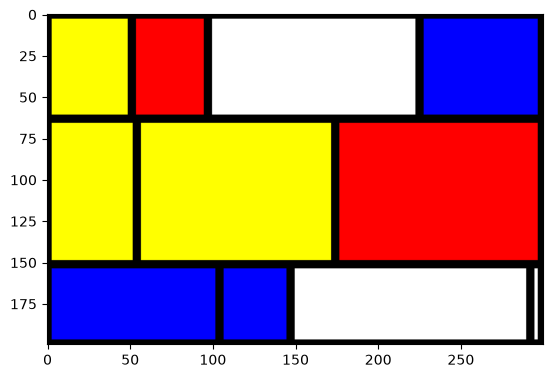

In [21]:
plt.imshow(paint_mondrian(width, height))
plt.show()

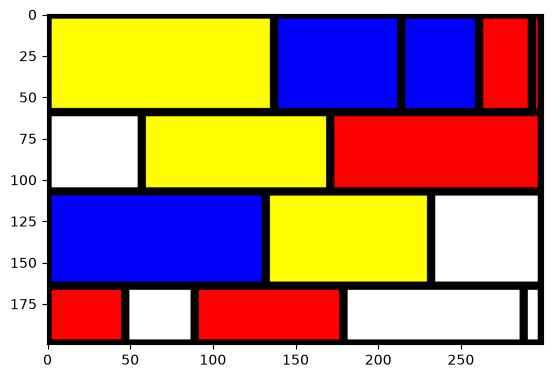

In [18]:
cv2.imwrite('mondrian.png', cv2.cvtColor(paint_mondrian(width, height), cv2.COLOR_BGR2RGB))
img = cv2.cvtColor(cv2.imread('mondrian.png'), cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.show()

### Tarea 3 - Detección de píxeles en vídeo

Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara.

En este caso, se ha elegido el color rojo para representar el píxel más claro, y el azul para mostrar el píxel más oscuro.
<br>
El resultado parece bastante fluido, no se aprecian tirones:

In [49]:
vid = cv2.VideoCapture(0)

while(True):
    ret, frame = vid.read()

    if ret:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        _, _, min_loc, max_loc = cv2.minMaxLoc(gray)
        cv2.circle(frame, min_loc, 10, (255, 0, 0), 2)
        cv2.circle(frame, max_loc, 10, (0, 0, 255), 2)

        cv2.imshow('Tarea3', frame)

    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()

### Tarea 4 - Pop Art al estilo de Warhol

Llevar a cabo una propuesta propia de Pop Art.

Para ello, se ha creado la función `get_warhol_transform()`, que devuelve una transformación de canal de color aleatoria:

In [ ]:
def get_warhol_transform():
    transforms = [
        lambda r, g, b: r.astype(np.int16) - g.astype(np.int16),
        lambda r, g, b: r.astype(np.int16) - b.astype(np.int16),
        lambda r, g, b: 255 - r,
        lambda r, g, b: r.astype(np.uint16) + g.astype(np.uint16),
        lambda r, g, b: r.astype(np.uint16) + b.astype(np.uint16),
        lambda r, g, b: b.astype(np.int16) - g.astype(np.int16),
        lambda r, g, b: b.astype(np.int16) - r.astype(np.int16),
        lambda r, g, b: 255 - b,
        lambda r, g, b: b.astype(np.uint16) + g.astype(np.uint16),
        lambda r, g, b: g.astype(np.int16) - b.astype(np.int16),
        lambda r, g, b: g.astype(np.int16) - r.astype(np.int16),
        lambda r, g, b: 255 - g,
        lambda r, g, b: r,
        lambda r, g, b: g,
        lambda r, g, b: b,
    ]
    return random.choice(transforms), random.choice(transforms), random.choice(transforms)

Esta función se ha utilizado para generar distintas combinaciones de Pop Art.
<br></br>
En nuestra composición, se genera un collage de tamaño 3x3, en el que cada sub-imagen utiliza una combinación de planos diferente y aleatoria.
<br></br>
Para cambiar las funciones transformadoras en ejecución, se puede pulsar la tecla `r`.

In [ ]:
vid = cv2.VideoCapture(0)

w = int(vid.get(cv2.CAP_PROP_FRAME_WIDTH)) // 3
h = int(vid.get(cv2.CAP_PROP_FRAME_HEIGHT)) // 3

warhol_transforms = [get_warhol_transform() for _ in range(9)]
collage = np.zeros((h * 3, w * 3, 3), dtype=np.uint8)

while True:
    ret, frame = vid.read()
    
    if ret:
        frame = cv2.resize(frame, (w, h), interpolation=cv2.INTER_NEAREST)
        b, g, r = frame[:, :, 0], frame[:, :, 1], frame[:, :, 2]

        for i in range(9):
            b_func, g_func, r_func = warhol_transforms[i]
            row, col = i // 3, i % 3

            collage[row * h : (row + 1) * h, col * w : (col + 1) * w] = cv2.merge(
                [np.clip(b_func(r, g, b), 0, 255).astype(np.uint8), 
                 np.clip(g_func(r, g, b), 0, 255).astype(np.uint8), 
                 np.clip(r_func(r, g, b), 0, 255).astype(np.uint8)]
            )

        cv2.imshow("Tarea4", collage)

        key = cv2.waitKey(20)
        if key == 27:
            break
        elif key == 114: # r = cambiar funciones
            warhol_transforms = [get_warhol_transform() for _ in range(9)]

vid.release()
cv2.destroyAllWindows()

### Tarea Extra
<br>
Haciendo uso de los conceptos aprendidos en las tareas 1-4, hemos realizado como tarea extra una herramienta de comparación entre color y detección de bordes.

In [ ]:
def mouse_events(event, x, y, flags, param):
    if event == cv2.EVENT_MOUSEMOVE:
        global px, py
        px, py = x, y

In [ ]:
vid = cv2.VideoCapture(0)
running = False
px, py = -1, -1

while(True):
    ret, frame = vid.read()
    if ret:
        if not running:
            cv2.imshow('TareaExtra', frame)
            cv2.setMouseCallback('TareaExtra', mouse_events)
            running = True
        
        bordes = cv2.cvtColor(cv2.Canny(frame, 75, 150), cv2.COLOR_GRAY2BGR)
    
        if px != -1 and py != -1:
            mask = np.zeros(frame.shape[:2], dtype=np.uint8)
            cv2.circle(mask, (px, py), 50, (255, 255, 255), -1)
            bordes[mask > 0] = frame[mask > 0]
        
        cv2.imshow('TareaExtra', bordes)
        
    if cv2.waitKey(20) == 27:
        break
  
vid.release()
cv2.destroyAllWindows()

412 467
403 398
402 386
401 384
401 383
401 380
399 372
394 351
391 345
391 345
391 345
391 345
391 345
391 345
391 345
391 345
387 334
375 302
366 275
362 264
360 259
358 256
355 254
352 253
348 253
340 253
335 255
331 257
325 263
323 267
321 272
319 277
318 281
318 284
320 288
322 292
326 297
327 299
331 301
334 301
336 302
338 302
338 303
340 304
341 305
341 306
341 307
341 309
341 311
341 314
342 317
342 319
342 322
342 322
342 323
342 323
342 323
342 323
342 323
342 323
343 323
343 323
343 323
343 323
343 323
343 322
340 320
334 317
329 315
325 313
323 313
322 311
321 310
320 309
319 305
317 301
317 300
317 298
317 297
317 297
317 297
317 297
317 297
317 297
317 297
317 297
317 297
317 297
317 297
317 297
317 297
298 302
270 305
245 305
229 305
223 305
219 305
218 305
217 305
217 305
217 305
217 305
217 305
217 305
217 305
217 305
228 307
242 309
246 310
252 310
254 310
256 310
258 310
259 310
262 310
266 310
269 309
273 309
276 309
278 309
281 309
282 309
286 310
291 313
295 315
